## 1. What this notebook computes

The Kohn-Sham equation of dirac16complex in the author's primordial field is an
equation for 16 complex functions of the eight coordinates $x_1, \dots, x_8$. This
notebook turns it, step by exact step, into eight independent equations for TWO
functions of ONE coordinate, the hidden coordinate $y$. Every step is computed here
with exact algebra (sympy) from the author's gamma matrices and compared with the
Revision record, which made the same computation twice (in sympy and in
WolframScript). The steps are:

- the hidden coordinate $y$ and the warped form of the author's metric
  (figures 1 and 2);
- the spin connection: the only term that survives in the Dirac operator is
  $3H\gamma^{(x_8)}$; the time-direction pieces of the three inflating and of the
  three deflating directions cancel (figure 3);
- the factor $W^{-3} = e^{-3Hy}$ in the orbital removes this term exactly;
- the equation becomes $i\,\partial_{x_4}\chi = h\,\chi$ with a Hermitian $h$;
- three matrices $J, K_1, K_2$ commute with $h$ and split the 16 components into
  eight blocks of two; the block basis $V$ is built and compared entry by entry
  with the Revision record (figure 4);
- in every block the equation is $h_j = j[-i\sigma_1\,d/dy + M\sigma_2 +
  \kappa k\sigma_3] + v$, and only two types of blocks exist ($j = \pm 1$);
- the chirality MATRIX $\Gamma$ maps a block of type $j$ with mass $M$ onto a
  block of type $-j$ with mass $-M$;
- the slice $a_{4,0}$ of the deflating history enters only through
  $k\,e^{-a_{4,0}}$: the exact rescaling identity (figure 5).

The notebook prints a line starting with PASS for every check (28 in all) and
saves five figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 14a (The reduction of the Kohn-Sham equation to eight 2x2 blocks and the
rescaling identity) is the file `Revision/textbook/notebooks/14a_block_reduction.ipynb`
of the repository Dirac_claude. It rebuilds from the author's real 16 x 16 gamma matrices
every exact step that turns the 16-component Kohn-Sham equation of dirac16complex in the
deflating primordial field into eight independent 2 x 2 equations in the hidden
coordinate y: the warped form of the metric, the spin-connection term 3H gamma^(x8) (the
time-direction pieces of the three inflating and the three deflating directions cancel),
the factor W^(-3) that removes it, the three commuting labels J, K1, K2 and the block
basis V, the block forms of every matrix of the equation, the chirality matrix Gamma that
pairs the blocks of opposite type and reverses the mass, and the exact rescaling identity
between the slices of the deflating history; it checks every step against the Revision
records and draws five teaching figures. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 14a_block_reduction.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 40 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 14a_block_reduction.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
14a_block_reduction.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/14a.captions.json`,
`Revision/textbook/figures/14a_1_hidden_coordinate.png`,
`Revision/textbook/figures/14a_2_inflation_deflation.png`,
`Revision/textbook/figures/14a_3_spin_connection_terms.png`,
`Revision/textbook/figures/14a_4_block_structure.png` and
`Revision/textbook/figures/14a_5_rescaling.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all five figure files of this notebook exist
    ALL 28 CHECKS PASSED (notebook 14a)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/14a_block_reduction.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- the cells of sections 7 and 8 seem to hang: they do exact algebra with 16 x 16 matrices
  of symbols and take about 10 seconds each on a laptop; wait until the PASS lines
  appear.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 14a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 14a (The reduction of the Kohn-Sham equation to eight 2x2 blocks and the
# rescaling identity) is the file Revision/textbook/notebooks/14a_block_reduction.ipynb
# of the repository Dirac_claude. It rebuilds from the author's real 16 x 16 gamma
# matrices every exact step that turns the 16-component Kohn-Sham equation of
# dirac16complex in the deflating primordial field into eight independent 2 x 2 equations
# in the hidden coordinate y: the warped form of the metric, the spin-connection term 3H
# gamma^(x8) (the time-direction pieces of the three inflating and the three deflating
# directions cancel), the factor W^(-3) that removes it, the three commuting labels J,
# K1, K2 and the block basis V, the block forms of every matrix of the equation, the
# chirality matrix Gamma that pairs the blocks of opposite type and reverses the mass,
# and the exact rescaling identity between the slices of the deflating history; it checks
# every step against the Revision records and draws five teaching figures. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 14a_block_reduction.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 40
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 14a_block_reduction.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 14a_block_reduction.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/14a.captions.json,
# Revision/textbook/figures/14a_1_hidden_coordinate.png,
# Revision/textbook/figures/14a_2_inflation_deflation.png,
# Revision/textbook/figures/14a_3_spin_connection_terms.png,
# Revision/textbook/figures/14a_4_block_structure.png and
# Revision/textbook/figures/14a_5_rescaling.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all five figure files of this notebook exist
#     ALL 28 CHECKS PASSED (notebook 14a)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/14a_block_reduction.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - the cells of sections 7 and 8 seem to hang: they do exact algebra with 16 x 16
#   matrices of symbols and take about 10 seconds each on a laptop; wait until the PASS
#   lines appear.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "14a"  # this notebook: chapter 14, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 14a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates $x_1, \dots, x_8$**: the author's names. $x_1, x_2, x_3$ are
  ordinary 3-space; $x_4$ is the time; $x_5, x_6, x_7$ are the three EXTRA TIMES;
  $x_8$ is the hidden space direction. In Python lists they have the positions
  0 to 7.
- **Metric, scale factor**: the metric says how long a small step $dx_\mu$ is.
  A scale factor multiplies a coordinate step: along $x_1$ a step $dx_1$ has the
  length $e^{a_4} \sin^{1/6} z \, dx_1$.
- **Inflating, deflating**: $a_4(x_4)$ grows with the time $x_4$. Then
  $e^{a_4}$ grows (3-space inflates) and $e^{-a_4}$ shrinks exponentially (the
  three extra times deflate).
- **Slice**: one instant $x_4$ of the history; $a_{4,0} = a_4(x_4)$ is the value
  of $a_4$ there. The history $a_4 = A H x_4$ is a PRESCRIBED BACKGROUND (it is
  given, not solved for, and the Kohn-Sham gas does not act back on it).
- **Hidden coordinate $y$**: $y = \ln(\sin z)/(6H)$ with $z = 6 H x_8$; it measures
  proper length along $x_8$.
- **Warp factor $W$**: $W = e^{Hy}$; the scale factors of the six directions
  $x_1, x_2, x_3, x_5, x_6, x_7$ contain $W$.
- **Gamma matrices $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$**: the author's real
  $16 \times 16$ matrices with $\gamma^a\gamma^b + \gamma^b\gamma^a =
  2\eta^{ab}$ (the Clifford relation); in the code `g1`, ..., `g8`.
- **Spin connection $\Omega_\mu$**: the matrices that the curvature of space adds
  to the derivative of a spinor: $D_\mu = \partial_\mu + \Omega_\mu$.
- **Hermitian matrix**: equal to its conjugate transpose, $X^\dagger = X$; its
  eigenvalues are real. **Unitary**: $V^\dagger V = 1$ (a change of basis that
  keeps lengths).
- **Commute, anticommute**: $XY = YX$, or $XY = -YX$.
- **Projector**: a matrix with $P^2 = P$; its rank is the dimension of the space
  it projects onto.
- **Block**: a $2 \times 2$ piece on the diagonal of a matrix that has no other
  nonzero entries in its rows and columns.
- **Pauli matrices** $\sigma_1 = [[0,1],[1,0]]$, $\sigma_2 = [[0,-i],[i,0]]$,
  $\sigma_3 = [[1,0],[0,-1]]$ (written row by row).
- **Chirality matrix $\Gamma$** $= \gamma^{(x_8)}\gamma^{(x_1)}\cdots
  \gamma^{(x_7)}$: a MATRIX (not a complex conjugation); here it equals
  diag$(-1, \dots, -1, 1, \dots, 1)$.
- **sympy**: computes exactly with symbols and fractions; a check made with
  sympy is an exact identity, not a numerical approximation.
- **Revision record**: the files under `Revision/` that hold the verified
  computations; a PASS line ending with "reproduces ..." names the record file
  and the check that this notebook computed again.

## 4. The physical and mathematical situation

The author's metric is diagonal. In the order $x_1, \dots, x_8$ its entries are
$e^{2a_4}\sin^{1/3}z$ (three times), $-1$, $-e^{-2a_4}\sin^{1/3}z$ (three times)
and $\cot^2 z$, with $z = 6Hx_8$ between $0$ and $\pi/2$ and $H > 0$. The signs
$\eta = (+,+,+,-,-,-,-,+)$ say which directions are space-like ($+$) and which
are time-like ($-$).

In the Kohn-Sham model (the mean-field description of many quanta) every quantum
obeys the equation

$$\gamma^\mu D_\mu \Psi = (M_{\rm eff} - i v_v \gamma^{(x_4)})\Psi ,$$

where $M_{\rm eff}(y)$ is the effective mass and $v_v(y)$ the vector potential
made by all the other quanta (their formulas are not needed here). We use the
GOOD SECTOR: $\Psi$ does not depend on the extra times $x_5, x_6, x_7$. This is
an ASSUMPTION of the Revision theory (modes that move along the extra times grow
without bound). We look for orbitals of the form

$$\Psi = e^{i \mathbf{k}\cdot\mathbf{x}}\, W(y)^{-3}\, \chi(y, x_4),$$

a plane wave with 3-momentum $\mathbf k$ along 3-space, the factor $W^{-3}$, and a
column $\chi$ of 16 functions of $y$ and the time. The notebook shows that
$\chi$ obeys $i\,\partial_{x_4}\chi = h\chi$ and that $h$ splits into eight
$2\times2$ blocks. At one instant (one slice) the stationary orbitals solve
$h\chi = \varepsilon\chi$: the stationary-slice (adiabatic) ansatz of the
Revision theory.

Status of the statements: every identity of this notebook is PROVED (exact, and
verified twice in the Revision record); the good sector is ASSUMED; the history
$a_4 = A H x_4$ is a PRESCRIBED BACKGROUND.

## 5. The author's gamma matrices

The Revision record `Revision/algebra/gammas.json` stores the eight matrices
$\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$ as lists of rows; `gamma[a]` is
$\gamma^{(x_{a+1})}$. The next cell reads them, turns them into exact sympy
matrices and checks the Clifford relation $\gamma^a\gamma^b + \gamma^b\gamma^a =
2\eta^{ab}\,1$ for all 64 pairs $(a, b)$. It also defines the helper
`record_check`, which reads the verdict of a named check from a Revision report;
every check below that repeats a Revision check also requires that the record
says PASS.

In [2]:
import numpy as np  # floating-point arrays and matrices
import sympy as sp  # exact algebra with symbols

PY_REPORT = "Revision/kohn_sham/reports/ks-theory-python.json"
WL_REPORT = "Revision/kohn_sham/reports/ks-theory-wolfram.json"


def record_check(name):
    """True when the check called name is PASS in the sympy record and, if the
    WolframScript record has a check of that name, PASS there too."""
    verdicts = {}
    for report in (PY_REPORT, WL_REPORT):
        data = json.loads(repository_file(report).read_text(encoding="utf-8"))
        found = [c["verdict"] for c in data["checks"] if c["name"] == name]
        verdicts[report] = found[0] if found else "absent"
    return (verdicts[PY_REPORT] == "PASS"
            and verdicts[WL_REPORT] in ("PASS", "absent"))


fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
g = [sp.Matrix(m) for m in fixture["gamma"]]  # g[0] = gamma^(x1) ... g[7] = gamma^(x8)
eta = [int(v) for v in fixture["eta"]]  # +1 space-like, -1 time-like
g1, g2, g3, g4, g5, g6, g7, g8 = g  # gN is gamma^(xN)
I16, Z16 = sp.eye(16), sp.zeros(16)  # the 16 x 16 unit and zero matrices
say(f"eta in the order x1 ... x8: {eta}")
entries = sorted({int(e) for m in g for e in m})  # the different entries
say(f"the entries of the eight gamma matrices are the integers {entries}")
clifford = all(g[a] * g[b] + g[b] * g[a] == (2 * eta[a] if a == b else 0) * I16
               for a in range(8) for b in range(8))
check(clifford and eta == [1, 1, 1, -1, -1, -1, -1, 1]
      and record_check("clifford_relation"),
      "the Clifford relation gamma^a gamma^b + gamma^b gamma^a = 2 eta^ab",
      record=f"{PY_REPORT}, check clifford_relation")

eta in the order x1 ... x8: [1, 1, 1, -1, -1, -1, -1, 1]
the entries of the eight gamma matrices are the integers [-1, 0, 1]
PASS the Clifford relation gamma^a gamma^b + gamma^b gamma^a = 2 eta^ab
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check clifford_relation


The next cell builds three products that the theory uses again and again:

- $C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$, the product of
  the four space-like gammas; the Dirac adjoint is $\bar\Psi = \Psi^\dagger C$.
- $B = -i\,C\,\gamma^{(x_4)}$, the matrix of the positive inner product of the
  good sector ($\langle\Psi^\dagger X \Psi\rangle = u^\dagger B X u$ for one
  quantum in the mode $u$).
- $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$, the chirality
  matrix.

It checks that $C$ is real and symmetric with $C^2 = 1$, that $B$ is Hermitian
with $B^2 = 1$, that $\Gamma$ is diagonal with eight entries $-1$ followed by
eight entries $+1$, and three product rules used later: $BC = -i\gamma^{(x_4)}$,
$C\gamma^{(x_4)} = iB$ and $CBC = B$. (`X.H` is the conjugate transpose
$X^\dagger$ in sympy and `X.T` the transpose.)

In [3]:
C = g8 * g1 * g2 * g3  # the matrix of the Dirac adjoint
B = -sp.I * C * g4  # the matrix of the positive inner product
Gamma = g8 * g1 * g2 * g3 * g4 * g5 * g6 * g7  # the chirality matrix
check(C.T == C and C * C == I16 and B.H == B and B * B == I16
      and Gamma == sp.diag(*([-1] * 8 + [1] * 8)) and record_check("C_B_Gamma"),
      "C real symmetric with C^2 = 1, B Hermitian with B^2 = 1, Gamma = diag(-1, 1)",
      record=f"{PY_REPORT}, check C_B_Gamma")
check(B * C == -sp.I * g4 and C * g4 == sp.I * B and C * B * C == B
      and record_check("BC_and_Cg4"),
      "BC = -i gamma^(x4), C gamma^(x4) = i B and C B C = B",
      record=f"{PY_REPORT}, check BC_and_Cg4")

PASS C real symmetric with C^2 = 1, B Hermitian with B^2 = 1, Gamma = diag(-1, 1)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check C_B_Gamma
PASS BC = -i gamma^(x4), C gamma^(x4) = i B and C B C = B
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check BC_and_Cg4


## 6. The hidden coordinate y and the warped form of the metric

Along $x_8$ the metric has the entry $g_{88} = \cot^2 z$ with $z = 6Hx_8$. We
replace $x_8$ by

$$y = \frac{\ln(\sin z)}{6H}.$$

Line by line:

1. Differentiate with the chain rule: $dy/dx_8 = \frac{1}{6H}\cdot\frac{\cos z}
   {\sin z}\cdot 6H = \cot z$.
2. Square: $dy^2 = \cot^2 z\, dx_8^2 = g_{88}\,dx_8^2$. So $y$ measures proper
   length along the hidden direction, and in the new coordinate the entry is 1.
3. Exponentiate the definition: $e^{6Hy} = \sin z$, hence $\sin^{1/3} z =
   e^{2Hy} = W^2$ with the warp factor $W = e^{Hy}$.
4. Range: $z \to 0$ (the TIP) gives $\sin z \to 0$ and $y \to -\infty$; $z =
   \pi/2$ (the end of the author's coordinate patch, the BRANE) gives $y = 0$.

The metric becomes the warped form

$$ds^2 = e^{2Hy}\left[e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2) - e^{-2a_4}(dx_5^2 +
dx_6^2 + dx_7^2)\right] - dx_4^2 + dy^2 .$$

Its scale factors (the vielbein entries) are $h = (e^{a_4}W, e^{a_4}W, e^{a_4}W,
1, e^{-a_4}W, e^{-a_4}W, e^{-a_4}W, 1)$. The square root of the absolute value
of the determinant is their product: $e^{3a_4}W^3\cdot e^{-3a_4}W^3 = W^6 =
e^{6Hy}$. In the author's $x_8$ chart it is $\sin z \cdot \cot z = \cos z$; the
two differ by the factor $dy/dx_8 = \cot z$ of step 1. Neither depends on $a_4$:
while 3-space inflates and the extra times deflate, the 7-volume stays the same.

The next cell verifies steps 1 to 3 and the determinant with sympy.

In [4]:
H = sp.symbols("H", positive=True)  # the author's constant H > 0
y_neg = sp.symbols("y", negative=True)  # the hidden coordinate inside the patch
x8, z = sp.symbols("x8 z", positive=True)
z_of_y = sp.asin(sp.exp(6 * H * y_neg))  # z(y): the solution of sin z = e^(6Hy)
dx8_dy = sp.diff(z_of_y / (6 * H), y_neg)  # x8 = z/(6H) differentiated in y
ok_line = sp.simplify(sp.cot(z_of_y) ** 2 * dx8_dy ** 2 - 1) == 0  # g88 dx8^2 = dy^2
ok_warp = sp.simplify(sp.sin(z_of_y) ** sp.Rational(1, 3)
                      - sp.exp(2 * H * y_neg)) == 0  # sin^(1/3) z = e^(2Hy)
ok_dy = sp.simplify(sp.diff(sp.log(sp.sin(6 * H * x8)) / (6 * H), x8)
                    - sp.cot(6 * H * x8)) == 0  # dy/dx8 = cot z
check(ok_line and ok_warp and ok_dy and record_check("geometry_hidden_coordinate"),
      "y = ln(sin z)/(6H): dy = cot z dx8 and sin^(1/3) z = e^(2Hy)",
      record=f"{PY_REPORT}, check geometry_hidden_coordinate")
a0 = sp.symbols("a0", real=True)  # the value of a4 at one slice
third = sp.Rational(1, 3)
metric_x8 = ([sp.exp(2 * a0) * sp.sin(z) ** third] * 3 + [-1]
             + [-sp.exp(-2 * a0) * sp.sin(z) ** third] * 3 + [sp.cot(z) ** 2])
det_x8 = sp.simplify(sp.Abs(sp.prod(metric_x8)))  # |det g| in the x8 chart
say(f"|det g| in the author's x8 chart = {det_x8}")
check(sp.simplify(det_x8 - sp.cos(z) ** 2) == 0 and record_check("geometry_sqrt_det"),
      "|det g| = cos^2 z in the x8 chart; it does not contain a4",
      record=f"{PY_REPORT}, check geometry_sqrt_det")

PASS y = ln(sin z)/(6H): dy = cot z dx8 and sin^(1/3) z = e^(2Hy)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    geometry_hidden_coordinate
|det g| in the author's x8 chart = cos(z)**2
PASS |det g| = cos^2 z in the x8 chart; it does not contain a4
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check geometry_sqrt_det


The next cell draws the change of coordinate (with $H = 1$). Left: $y$ as a
function of $z$; at the tip $z \to 0$ the coordinate $y$ falls to $-\infty$, at
the brane $z = \pi/2$ it is 0. Right: three factors along $y$ from $-3$ to $0$
(the Rust solver cuts the hidden direction at $y = -L = -3$): the warp factor
$W = e^{Hy}$, the factor $\sin^{1/3}z = W^2$ of the metric and the volume factor
$\sqrt{|g|} = W^6$ (the proper 7-volume per unit coordinate volume). The
vertical axis is logarithmic, so each exponential is a straight line with slope
1, 2 or 6.

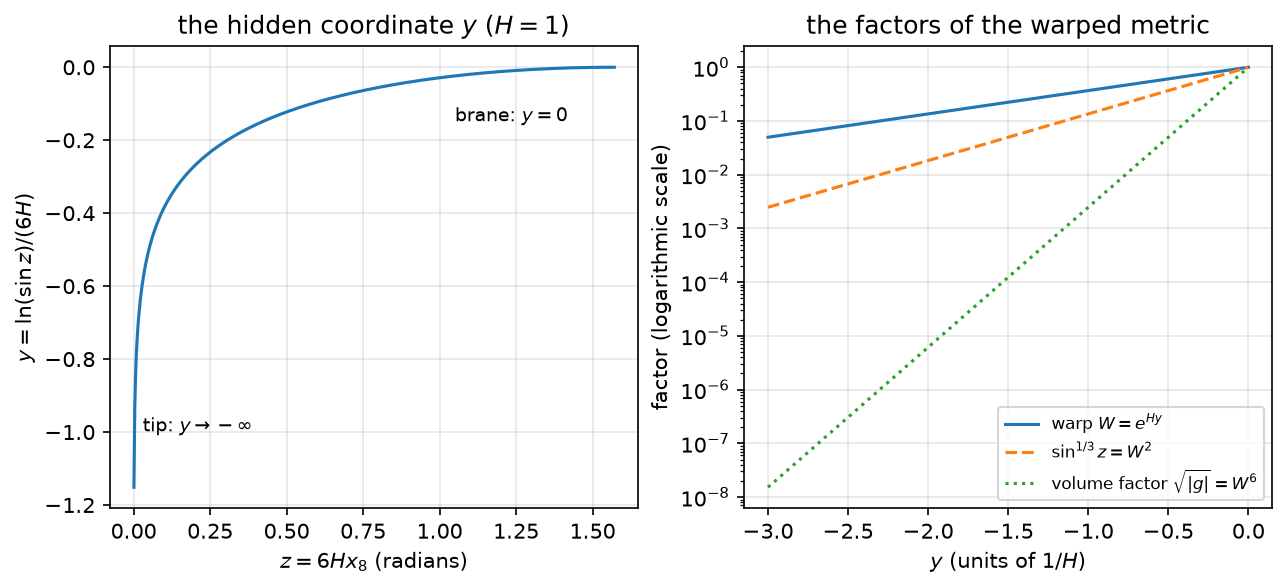

Figure 14a.1 saved as Revision/textbook/figures/14a_1_hidden_coordinate.png


In [5]:
z_values = np.linspace(1e-3, np.pi / 2, 600)  # z from almost 0 to pi/2
y_of_z = np.log(np.sin(z_values)) / 6.0  # y = ln(sin z)/(6H) with H = 1
y_values = np.linspace(-3.0, 0.0, 301)  # the hidden coordinate from -L to 0

fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(z_values, y_of_z, color="C0")
left.set_xlabel("$z = 6 H x_8$ (radians)")
left.set_ylabel("$y = \\ln(\\sin z)/(6H)$")
left.set_title("the hidden coordinate $y$ ($H = 1$)")
left.annotate("tip: $y \\to -\\infty$", (0.03, -1.0), fontsize=9)
left.annotate("brane: $y = 0$", (1.05, -0.15), fontsize=9)
right.semilogy(y_values, np.exp(y_values), label="warp $W = e^{Hy}$")
right.semilogy(y_values, np.exp(2 * y_values), "--",
               label="$\\sin^{1/3} z = W^2$")
right.semilogy(y_values, np.exp(6 * y_values), ":",
               label="volume factor $\\sqrt{|g|} = W^6$")
right.set_xlabel("$y$ (units of $1/H$)")
right.set_ylabel("factor (logarithmic scale)")
right.set_title("the factors of the warped metric")
right.legend(fontsize=8)
save_figure(fig, "hidden_coordinate",
            "Left: the hidden coordinate $y = \\ln(\\sin z)/(6H)$ against "
            "$z = 6Hx_8$ (radians) for $H = 1$; $y$ tends to minus infinity at the "
            "tip $z \\to 0$ and is $0$ at the brane $z = \\pi/2$. Right: the warp "
            "factor $W = e^{Hy}$ (solid), the metric factor $\\sin^{1/3} z = W^2$ "
            "(dashed) and the volume factor $\\sqrt{|g|} = W^6$ (dotted) against "
            "$y$ from $-3$ to $0$ in units of $1/H$, on a logarithmic vertical "
            "axis; the three straight lines have the slopes 1, 2 and 6, and the "
            "proper 7-volume near the tip is smaller than at the brane by the "
            "factor $e^{-18}$.")

The next cell draws what the deflating history does. Left: along the PRESCRIBED
history $a_4 = A H x_4$ with $A = H = 1$ (so $a_4 = x_4$), the 3-space scale
factor $e^{a_4}$ grows, the extra-time scale factor $e^{-a_4}$ shrinks, and the
product of their cubes, $e^{3a_4}e^{-3a_4} = 1$ (the 7-volume), stays constant.
Right: the MOMENTUM WEIGHT $\kappa(y) = e^{-Hy - a_{4,0}}$ against $y$ at the five
slices $a_{4,0} = 0, 0.5, 1, 1.5, 2$ of the Revision Rust solver. Section 8 shows
that a 3-momentum $k$ enters the equation only as $\kappa k$: the weight grows
toward the tip (a momentum costs more energy far from the brane) and drops by
$e^{-a_{4,0}}$ from slice to slice (the 3-momenta are redshifted).

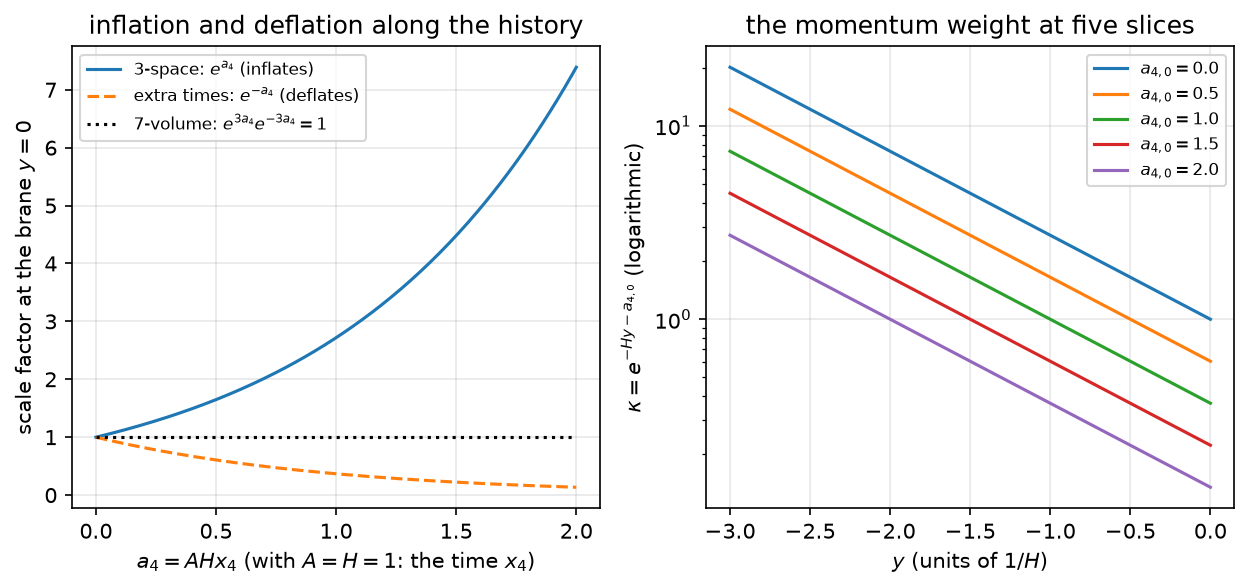

Figure 14a.2 saved as Revision/textbook/figures/14a_2_inflation_deflation.png


In [6]:
a4_values = np.linspace(0.0, 2.0, 201)  # a4 along the history (= x4 for A = H = 1)
slices = [0.0, 0.5, 1.0, 1.5, 2.0]  # the five slices of the Revision solver

fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(a4_values, np.exp(a4_values), label="3-space: $e^{a_4}$ (inflates)")
left.plot(a4_values, np.exp(-a4_values), "--",
          label="extra times: $e^{-a_4}$ (deflates)")
left.plot(a4_values, np.exp(3 * a4_values) * np.exp(-3 * a4_values), ":",
          color="black", label="7-volume: $e^{3a_4} e^{-3a_4} = 1$")
left.set_xlabel("$a_4 = A H x_4$ (with $A = H = 1$: the time $x_4$)")
left.set_ylabel("scale factor at the brane $y = 0$")
left.set_title("inflation and deflation along the history")
left.legend(fontsize=8)
for a in slices:  # one curve per slice
    right.semilogy(y_values, np.exp(-y_values - a), label=f"$a_{{4,0}} = {a}$")
right.set_xlabel("$y$ (units of $1/H$)")
right.set_ylabel("$\\kappa = e^{-Hy - a_{4,0}}$ (logarithmic)")
right.set_title("the momentum weight at five slices")
right.legend(fontsize=8)
save_figure(fig, "inflation_deflation",
            "Left: along the prescribed history $a_4 = A H x_4$ with $A = H = 1$, "
            "the 3-space scale factor $e^{a_4}$ (solid) grows, the scale factor "
            "$e^{-a_4}$ of the three extra times (dashed) deflates exponentially, "
            "and the 7-volume factor $e^{3a_4}e^{-3a_4} = 1$ (dotted) stays "
            "constant; horizontal axis $a_4$, vertical axis the scale factor at "
            "the brane $y = 0$. Right: the momentum weight "
            "$\\kappa = e^{-Hy - a_{4,0}}$ against $y$ (units of $1/H$) at the "
            "five slices $a_{4,0} = 0$ to $2$, logarithmic vertical axis: the "
            "weight grows toward the tip and every later slice lies lower by the "
            "factor $e^{-0.5}$, the redshift of the 3-momenta.")

## 7. The spin connection and the term 3H gamma^(x8)

A spinor needs the covariant derivative $D_\mu\Psi = \partial_\mu\Psi +
\Omega_\mu\Psi$. For the diagonal vielbein $h_a$ of section 6 the canonical spin
connection (the one fixed by the vielbein postulate) is computed in three steps:

1. The Christoffel symbols $\Gamma^n_{mk} = \frac12 g^{nl}(\partial_m g_{lk} +
   \partial_k g_{lm} - \partial_l g_{mk})$. For a diagonal metric only the terms
   with two equal indices survive: $\Gamma^n_{mk} = [\delta_{mn}\partial_k g_{nn}
   + \delta_{kn}\partial_m g_{nn} - \delta_{mk}\partial_n g_{mm}]/(2g_{nn})$.
2. The connection coefficients $\omega_\mu{}^A{}_B = h_A\,\partial_\mu(1/h_B)\,
   \delta^A_B + h_A\,\Gamma^A_{\mu B}/h_B$ (no sum over $A$, $B$).
3. $\Omega_\mu = \frac12\sum_{A,B}\eta_{AA}\,\omega_\mu{}^A{}_B\,S^{AB}$ with
   $S^{AB} = \frac14(\gamma^A\gamma^B - \gamma^B\gamma^A)$.

The next cell does these three steps with $a_4$ an arbitrary function of $x_4$
(so it holds along any history), checks that the curved gammas $\gamma^\mu =
\gamma^{(\mu)}/h_\mu$ are covariantly constant ($\nabla_\mu\gamma^\nu = 0$: 64
matrix equations, the proof that the connection is the right one), and computes
the only combination that enters the Dirac operator,
$\gamma^\mu\Omega_\mu = \sum_\mu (\gamma^{(\mu)}/h_\mu)\,\Omega_\mu$. It takes
about 10 seconds.

In [7]:
X = sp.symbols("x1:8", real=True) + (sp.Symbol("y", real=True),)  # x1..x7 and y
Y, x4 = X[7], X[3]  # the hidden coordinate and the time
a4 = sp.Function("a4", real=True)(x4)  # a4 is any function of the time x4
a4p = sp.diff(a4, x4)  # its derivative a4'
W = sp.exp(H * Y)  # the warp factor
vb = [sp.exp(a4) * W] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * W] * 3 + [sp.Integer(1)]
gdiag = [eta[i] * vb[i] ** 2 for i in range(8)]  # the diagonal metric entries


def christoffel(n, m, k):
    """Gamma^n_mk of the diagonal metric gdiag (step 1)."""
    total = 0
    if m == n:
        total += sp.diff(gdiag[n], X[k])
    if k == n:
        total += sp.diff(gdiag[n], X[m])
    if m == k:
        total -= sp.diff(gdiag[m], X[n])
    return sp.simplify(total / (2 * gdiag[n]))


Chr = [[[christoffel(n, m, k) for k in range(8)] for m in range(8)]
       for n in range(8)]
S = [[(g[a] * g[b] - g[b] * g[a]) / 4 for b in range(8)] for a in range(8)]
Omega = []  # Omega[mu] is the 16 x 16 matrix Omega_mu
for mu in range(8):
    total = sp.zeros(16)
    for A in range(8):
        for Bi in range(8):
            w = (vb[A] * sp.diff(1 / vb[Bi], X[mu]) if A == Bi else 0) \
                + vb[A] * Chr[A][mu][Bi] / vb[Bi]  # omega_mu^A_B (step 2)
            w = sp.simplify(w)
            if w != 0:
                total += sp.Rational(1, 2) * eta[A] * w * S[A][Bi]  # step 3
    Omega.append(sp.simplify(total))
compatible = all(
    (sp.diff(g[n] / vb[n], X[m])
     + sum((Chr[n][m][l] * g[l] / vb[l] for l in range(8)), Z16)
     + Omega[m] * g[n] / vb[n] - g[n] / vb[n] * Omega[m]).applyfunc(sp.simplify)
    .is_zero_matrix for m in range(8) for n in range(8))
check(compatible and record_check("spin_connection_compatibility"),
      "the curved gammas are covariantly constant (64 matrix equations)",
      record=f"{PY_REPORT}, check spin_connection_compatibility")
slash = sp.simplify(sum((g[m] / vb[m] * Omega[m] for m in range(8)), Z16))
check((slash - 3 * H * g8).is_zero_matrix and record_check("spin_connection_slash_3H"),
      "gamma^mu Omega_mu = 3H gamma^(x8) exactly, for every history a4(x4)",
      record=f"{PY_REPORT}, check spin_connection_slash_3H")

PASS the curved gammas are covariantly constant (64 matrix equations)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    spin_connection_compatibility
PASS gamma^mu Omega_mu = 3H gamma^(x8) exactly, for every history a4(x4)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    spin_connection_slash_3H


Where does $3H\gamma^{(x_8)}$ come from, and where did the time derivative $a_4'$
go? The next cell splits $\gamma^\mu\Omega_\mu$ into the contributions of the
eight directions. Each contribution $(\gamma^{(\mu)}/h_\mu)\Omega_\mu$ turns out
to be a combination $c_4\gamma^{(x_4)} + c_8\gamma^{(x_8)}$. Because
$\gamma^{(x_4)}\gamma^{(x_4)} = -1$, $\gamma^{(x_8)}\gamma^{(x_8)} = +1$ and the
trace of $\gamma^{(x_4)}\gamma^{(x_8)}$ is 0, the coefficients are found with
traces: $c_4 = -\mathrm{Tr}(X\gamma^{(x_4)})/16$ and $c_8 =
\mathrm{Tr}(X\gamma^{(x_8)})/16$. The cell checks that each contribution is
exactly $c_4\gamma^{(x_4)} + c_8\gamma^{(x_8)}$, prints the coefficients, and
checks the two facts of the Revision record: the three inflating directions give
$+\frac32 a_4'\gamma^{(x_4)}$, the three deflating directions give
$-\frac32 a_4'\gamma^{(x_4)}$, so the time-direction pieces cancel; and
$\Omega_{x_4} = \Omega_y = 0$.

In [8]:
names = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8 (y)"]
c4_list, c8_list = [], []  # the coefficients of gamma^(x4) and gamma^(x8)
split_ok = True
for m in range(8):
    part = sp.simplify(g[m] / vb[m] * Omega[m])  # the contribution of direction m
    c4 = sp.simplify(-(part * g4).trace() / 16)
    c8 = sp.simplify((part * g8).trace() / 16)
    split_ok &= (part - c4 * g4 - c8 * g8).applyfunc(sp.simplify).is_zero_matrix
    c4_list.append(c4)
    c8_list.append(c8)
    say(f"direction {names[m]:7}: c4 = {str(c4):26} c8 = {c8}")
check(split_ok, "every contribution is c4 gamma^(x4) + c8 gamma^(x8)")
inflating = sp.simplify(sum(c4_list[0:3]))  # x1, x2, x3
deflating = sp.simplify(sum(c4_list[4:7]))  # x5, x6, x7
say(f"sum of c4 over the inflating directions x1, x2, x3: {inflating}")
say(f"sum of c4 over the deflating directions x5, x6, x7: {deflating}")
say(f"sum of c8 over all directions: {sp.simplify(sum(c8_list))}")
check(sp.simplify(inflating - sp.Rational(3, 2) * a4p) == 0
      and sp.simplify(deflating + sp.Rational(3, 2) * a4p) == 0
      and Omega[3].is_zero_matrix and Omega[7].is_zero_matrix
      and record_check("spin_connection_time_terms_cancel")
      and record_check("spin_connection_time_term_value"),
      "the a4' pieces +3/2 and -3/2 cancel; Omega_x4 = Omega_y = 0",
      record=f"{PY_REPORT}, checks spin_connection_time_terms_cancel and "
             "spin_connection_time_term_value")

direction x1     : c4 = Derivative(a4(x4), x4)/2   c8 = H/2
direction x2     : c4 = Derivative(a4(x4), x4)/2   c8 = H/2
direction x3     : c4 = Derivative(a4(x4), x4)/2   c8 = H/2
direction x4     : c4 = 0                          c8 = 0
direction x5     : c4 = -Derivative(a4(x4), x4)/2  c8 = H/2
direction x6     : c4 = -Derivative(a4(x4), x4)/2  c8 = H/2
direction x7     : c4 = -Derivative(a4(x4), x4)/2  c8 = H/2
direction x8 (y) : c4 = 0                          c8 = 0
PASS every contribution is c4 gamma^(x4) + c8 gamma^(x8)
sum of c4 over the inflating directions x1, x2, x3: 3*Derivative(a4(x4), x4)/2
sum of c4 over the deflating directions x5, x6, x7: -3*Derivative(a4(x4), x4)/2
sum of c8 over all directions: 3*H
PASS the a4' pieces +3/2 and -3/2 cancel; Omega_x4 = Omega_y = 0
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, checks
    spin_connection_time_terms_cancel and spin_connection_time_term_value


The next cell draws these coefficients as a bar chart, with the numbers
$a_4' = 1$ and $H = 1$ put in: for each direction one bar for the coefficient of
$\gamma^{(x_4)}$ and one bar for the coefficient of $\gamma^{(x_8)}$.

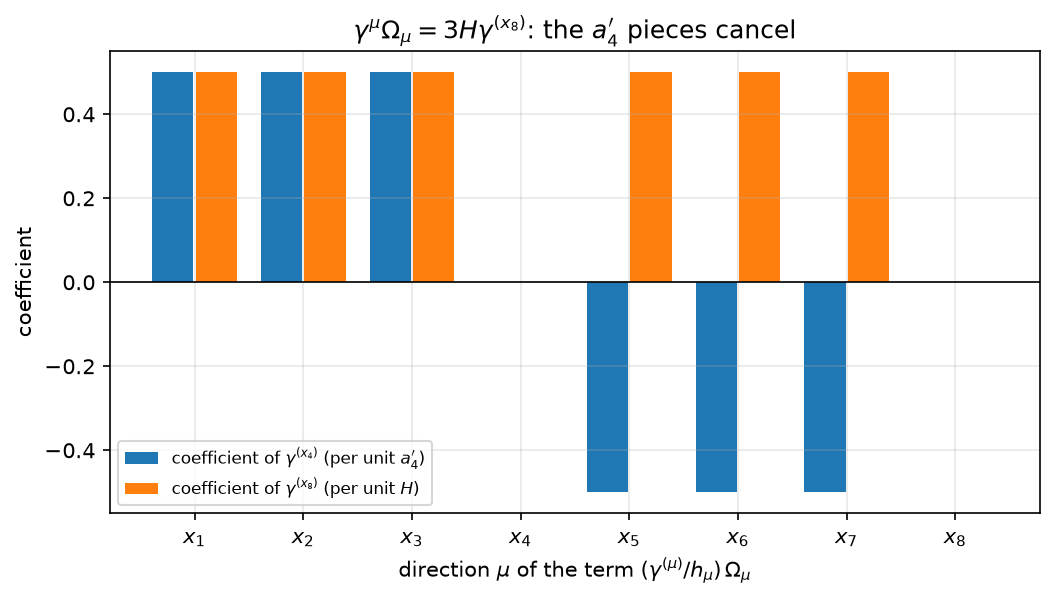

Figure 14a.3 saved as Revision/textbook/figures/14a_3_spin_connection_terms.png


In [9]:
c4_numbers = [float(c.subs(a4p, 1).subs(H, 1)) for c in c4_list]  # a4' = 1, H = 1
c8_numbers = [float(c.subs(a4p, 1).subs(H, 1)) for c in c8_list]
positions = np.arange(8)  # one group of two bars per direction

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(positions - 0.2, c4_numbers, width=0.38,
       label="coefficient of $\\gamma^{(x_4)}$ (per unit $a_4'$)")
ax.bar(positions + 0.2, c8_numbers, width=0.38,
       label="coefficient of $\\gamma^{(x_8)}$ (per unit $H$)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(["$x_1$", "$x_2$", "$x_3$", "$x_4$", "$x_5$", "$x_6$", "$x_7$",
                    "$x_8$"])
ax.set_xlabel("direction $\\mu$ of the term $(\\gamma^{(\\mu)}/h_\\mu)\\,"
              "\\Omega_\\mu$")
ax.set_ylabel("coefficient")
ax.set_title("$\\gamma^\\mu\\Omega_\\mu = 3H\\gamma^{(x_8)}$: "
             "the $a_4'$ pieces cancel")
ax.legend(fontsize=8)
save_figure(fig, "spin_connection_terms",
            "The contribution of each direction $\\mu$ to "
            "$\\gamma^\\mu\\Omega_\\mu$, written as "
            "$c_4\\gamma^{(x_4)} + c_8\\gamma^{(x_8)}$: the bars show $c_4$ per "
            "unit $a_4'$ (left bar of each pair) and $c_8$ per unit $H$ (right "
            "bar). The inflating directions $x_1, x_2, x_3$ give $+a_4'/2$ each "
            "and the deflating extra times $x_5, x_6, x_7$ give $-a_4'/2$ each, so "
            "the time-direction pieces cancel; each of the six warped directions "
            "gives $H/2$ to the coefficient of $\\gamma^{(x_8)}$, in total $3H$; "
            "the time $x_4$ and the hidden direction give nothing.")

## 8. The factor W^(-3) removes the spin connection

Insert $\Psi = e^{i\mathbf k\cdot\mathbf x}W^{-3}\chi(y, x_4)$ into
$\gamma^\mu D_\mu\Psi = \sum_\mu\gamma^\mu\partial_\mu\Psi + 3H\gamma^{(x_8)}\Psi$
(section 7). Term by term:

1. $y$: $\partial_y(W^{-3}\chi) = W^{-3}(\partial_y\chi - 3H\chi)$ because
   $\partial_y e^{-3Hy} = -3He^{-3Hy}$. With $\gamma^y = \gamma^{(x_8)}$ the term
   $-3H\gamma^{(x_8)}\chi$ cancels the $+3H\gamma^{(x_8)}\chi$ of the spin
   connection.
2. 3-space: $\partial_j e^{i\mathbf k\cdot\mathbf x} = ik_j e^{i\mathbf k\cdot
   \mathbf x}$ and $\gamma^{x_j} = \gamma^{(x_j)}/(e^{a_4}W)$, so the term is
   $i\kappa k_j\gamma^{(x_j)}$ with the momentum weight $\kappa = e^{-Hy-a_4}$.
3. Time: $\gamma^{x_4} = \gamma^{(x_4)}$ acts on $\partial_{x_4}\chi$.
4. Extra times: nothing depends on $x_5, x_6, x_7$ (good sector).

So, dividing by the common factor $e^{i\mathbf k\cdot\mathbf x}W^{-3}$:

$$\gamma^\mu D_\mu\Psi \to \gamma^{(x_8)}\partial_y\chi + \gamma^{(x_4)}
\partial_{x_4}\chi + i\kappa\,k_j\gamma^{(x_j)}\chi .$$

The next cell verifies this with sympy for a column of 16 arbitrary functions
$\chi_A(y, x_4)$ and an arbitrary history $a_4(x_4)$, and verifies that WITHOUT
the factor $W^{-3}$ the term $3H\gamma^{(x_8)}\chi$ survives. It takes about 5
seconds.

In [10]:
k1, k2, k3 = sp.symbols("k1 k2 k3", real=True)  # the 3-momentum
chi = sp.Matrix([sp.Function(f"chi{i}")(Y, x4) for i in range(16)])
phase = sp.exp(sp.I * (k1 * X[0] + k2 * X[1] + k3 * X[2]))  # the plane wave
kappa = sp.exp(-H * Y - a4)  # the momentum weight


def dirac(Psi):
    """gamma^mu D_mu Psi with the spin connection of section 7."""
    result = sp.zeros(16, 1)
    for m in range(8):
        result += g[m] / vb[m] * (sp.diff(Psi, X[m]) + Omega[m] * Psi)
    return result


reduced = (g8 * sp.diff(chi, Y) + g4 * sp.diff(chi, x4)
           + sp.I * kappa * (k1 * g1 + k2 * g2 + k3 * g3) * chi)
with_W3 = sp.simplify(dirac(phase * W ** -3 * chi) / (phase * W ** -3))
without_W3 = sp.simplify(dirac(phase * chi) / phase)
check((with_W3 - reduced).applyfunc(sp.simplify).is_zero_matrix
      and record_check("ansatz_removes_spin_connection"),
      "with W^(-3): the reduced operator g8 d_y + g4 d_x4 + i kappa k.g, exactly",
      record=f"{PY_REPORT}, check ansatz_removes_spin_connection")
check((without_W3 - reduced - 3 * H * g8 * chi).applyfunc(sp.simplify)
      .is_zero_matrix and record_check("ansatz_without_W3_term_survives"),
      "without W^(-3) the term 3H gamma^(x8) chi survives",
      record=f"{PY_REPORT}, check ansatz_without_W3_term_survives")

PASS with W^(-3): the reduced operator g8 d_y + g4 d_x4 + i kappa k.g, exactly
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    ansatz_removes_spin_connection
PASS without W^(-3) the term 3H gamma^(x8) chi survives
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    ansatz_without_W3_term_survives


## 9. The equation i d_x4 chi = h chi and its Hermitian pieces

With the reduced operator of section 8 the Kohn-Sham equation reads

$$\gamma^{(x_8)}\partial_y\chi + \gamma^{(x_4)}\partial_{x_4}\chi +
i\kappa k_j\gamma^{(x_j)}\chi = (M - iv\gamma^{(x_4)})\chi$$

($M$ the effective mass, $v$ the vector potential). Solve for the time
derivative, line by line:

1. Move everything except the time term to the right: $\gamma^{(x_4)}
   \partial_{x_4}\chi = (M - iv\gamma^{(x_4)})\chi - \gamma^{(x_8)}\partial_y\chi
   - i\kappa k_j\gamma^{(x_j)}\chi$.
2. Multiply from the left by $-\gamma^{(x_4)}$; since $\gamma^{(x_4)}
   \gamma^{(x_4)} = -1$, the left side becomes $\partial_{x_4}\chi$.
3. Multiply by $i$: $i\partial_{x_4}\chi = h\chi$ with
   $h = i\gamma^{(x_4)}\gamma^{(x_8)}\partial_y - \kappa k_j\gamma^{(x_4)}
   \gamma^{(x_j)} + M(-i\gamma^{(x_4)}) + v$.

$h$ is Hermitian (so the levels are real and the norm $\int\chi^\dagger\chi\,dy$
is conserved) because: $\gamma^{(x_4)}\gamma^{(x_8)}$ is real and symmetric, so
$i\gamma^{(x_4)}\gamma^{(x_8)}$ is anti-Hermitian, and $\partial_y$ is
anti-Hermitian too (integration by parts when the boundary terms vanish), so their
product is Hermitian; $\gamma^{(x_4)}\gamma^{(x_j)}$ and $-i\gamma^{(x_4)}$ are
Hermitian matrices. The next cell checks the three lines with 16-component
columns of symbols for $\partial_y\chi$ and $\chi$, and the Hermitian pieces.

In [11]:
M, v = sp.symbols("M v", real=True)  # effective mass and vector potential
chi_s = sp.Matrix(sp.symbols("c0:16"))  # chi at one point (16 symbols)
dchi_s = sp.Matrix(sp.symbols("d0:16"))  # d chi/dy at that point
kap = sp.symbols("kappa", positive=True)
kg = kap * (k1 * g1 + k2 * g2 + k3 * g3)  # kappa k.gamma
# line 1 and 2: d chi/dx4 = -g4 [(M - i v g4) chi - g8 chi' - i kappa k.g chi]
dt_chi = -g4 * ((M * I16 - sp.I * v * g4) * chi_s - g8 * dchi_s - sp.I * kg * chi_s)
# line 3: h chi with the four pieces of h
h_chi = (sp.I * g4 * g8 * dchi_s - kap * g4 * (k1 * g1 + k2 * g2 + k3 * g3) * chi_s
         + M * (-sp.I * g4) * chi_s + v * chi_s)
check((sp.I * dt_chi - h_chi).expand().is_zero_matrix,
      "i d_x4 chi = h chi with h = i g4 g8 d_y - kappa k_j g4 g_j + M(-i g4) + v")
hermitian = ((g4 * g8).T == g4 * g8 and all((-g4 * gj).H == -g4 * gj
                                            for gj in (g1, g2, g3))
             and (-sp.I * g4).H == -sp.I * g4 and (-sp.I * g4) ** 2 == I16)
check(hermitian and record_check("hamiltonian_16_hermitian"),
      "g4 g8 real symmetric; g4 g_j and -i g4 Hermitian; (-i g4)^2 = 1",
      record=f"{PY_REPORT}, check hamiltonian_16_hermitian")

PASS i d_x4 chi = h chi with h = i g4 g8 d_y - kappa k_j g4 g_j + M(-i g4) + v
PASS g4 g8 real symmetric; g4 g_j and -i g4 Hermitian; (-i g4)^2 = 1
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    hamiltonian_16_hermitian


## 10. Three matrices that commute with everything: J, K1, K2

Rotations of 3-space do not change the levels (section 14), so we may take
$\mathbf k = (k, 0, 0)$ along $x_1$. Then $h$ contains only the three matrices
$A_0 = \gamma^{(x_8)}$, $A_1 = \gamma^{(x_8)}\gamma^{(x_1)}$,
$A_4 = \gamma^{(x_8)}\gamma^{(x_4)}$ (multiply $h$ by $\gamma^{(x_8)}$ to see
it), and the densities contain $B$ and $C$.

A rule for products of different gammas: moving $\gamma^c$ through a product of
$p$ different gammas gives the sign $(-1)^{p-1}$ if $\gamma^c$ is one of the
factors and $(-1)^p$ if it is not. With it one finds three matrices that commute
with $A_0, A_1, A_4, B, C$ and with each other:

$$J = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_4)},\quad K_1 = \gamma^{(x_2)}
\gamma^{(x_3)},\quad K_2 = \gamma^{(x_5)}\gamma^{(x_6)} .$$

Their squares: $J^2 = (-1)^3(\gamma^{(x_8)})^2(\gamma^{(x_1)})^2(\gamma^{(x_4)})^2
= (-1)(1)(1)(-1) = +1$ (reversing three factors needs three swaps), $K_1^2 =
-(\gamma^{(x_2)})^2(\gamma^{(x_3)})^2 = -1$, $K_2^2 = -(-1)(-1) = -1$. So $J$
has the eigenvalues $j = \pm1$ and $K_1, K_2$ the eigenvalues $is_2, is_3$ with
$s_2, s_3 = \pm1$. The joint eigenspace with the labels $(j, s_2, s_3)$ is the
range of the projector

$$P(j, s_2, s_3) = \frac{1 + jJ}{2}\cdot\frac{1 - is_2K_1}{2}\cdot
\frac{1 - is_3K_2}{2} .$$

The next cell checks the commutation relations and the squares, builds the
eight projectors and checks that each has rank 2, that $P^2 = P$, and that the
eight add up to the unit matrix: the 16 components split into 8 blocks of 2.

In [12]:
A0, A1, A4 = g8, g8 * g1, g8 * g4  # the matrices of the equation (k along x1)
J, K1, K2 = g8 * g1 * g4, g2 * g3, g5 * g6
commute = all((P * Q - Q * P).is_zero_matrix for P in (J, K1, K2)
              for Q in (A0, A1, A4, B, C, J, K1, K2))
check(commute and J * J == I16 and K1 * K1 == -I16 and K2 * K2 == -I16
      and record_check("blocks_commuting_set"),
      "J, K1, K2 commute with A0, A1, A4, B, C and each other; J^2 = 1, K^2 = -1",
      record=f"{PY_REPORT}, check blocks_commuting_set")
labels = [(j, s2, s3) for j in (1, -1) for s2 in (1, -1) for s3 in (1, -1)]
projectors = [(I16 + j * J) / 2 * (I16 - sp.I * s2 * K1) / 2
              * (I16 - sp.I * s3 * K2) / 2 for (j, s2, s3) in labels]
check(all(P.rank() == 2 and (P * P - P).is_zero_matrix for P in projectors)
      and sum(projectors, Z16) == I16 and record_check("blocks_projectors"),
      "eight projectors P(j, s2, s3) of rank 2 that add up to 1",
      record=f"{PY_REPORT}, check blocks_projectors")

PASS J, K1, K2 commute with A0, A1, A4, B, C and each other; J^2 = 1, K^2 = -1
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    blocks_commuting_set
PASS eight projectors P(j, s2, s3) of rank 2 that add up to 1
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check blocks_projectors


## 11. The block basis V

In each eigenspace we choose two basis vectors adapted to the equation. Since
$A_0 = \gamma^{(x_8)}$ squares to 1, $\frac12(1 + \gamma^{(x_8)})$ projects on its
eigenvalue $+1$. Take the first unit column $e_c$ (counting $c$ from 0) for which
$v_+ = 8\,P(j, s_2, s_3)\,\frac12(1 + \gamma^{(x_8)})\,e_c$ is not zero; then
$\gamma^{(x_8)}v_+ = v_+$. Put $v_- = A_1v_+$. Because $A_1$ anticommutes with
$A_0$, $\gamma^{(x_8)}v_- = -v_-$. The 16 columns $v_+, v_-$ of the eight blocks,
in the label order $(1,1,1), (1,1,-1), \dots, (-1,-1,-1)$, form the matrix $U$,
and $V = U/(2\sqrt2)$.

The next cell builds $U$ and $V$, prints the seed columns $c$, checks that $V$
is unitary and that every entry of $U$ is $0$, $\pm1$ or $\pm i$, and compares $U$
entry by entry with the basis stored in the Revision record
`Revision/kohn_sham/ks-theory.json` (which the Rust solver uses).

In [13]:
columns, seeds = [], []
for P in projectors:
    P_plus = P * (I16 + g8) / 2  # project on gamma^(x8) = +1 inside the block
    c = next(c for c in range(16) if not P_plus[:, c].is_zero_matrix)
    seeds.append(c)
    v_plus = 8 * P_plus[:, c]
    columns += [v_plus, A1 * v_plus]  # v+ and v- = A1 v+
U = sp.Matrix.hstack(*columns)  # 16 x 16, entries 0, +-1, +-i
V = U / (2 * sp.sqrt(2))  # the unitary block basis
say(f"seed columns c of the eight blocks: {seeds}")
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json")
                    .read_text(encoding="utf-8"))
as_number = {"0": 0, "1": 1, "-1": -1, "I": sp.I, "-I": -sp.I}
U_record = sp.Matrix([[as_number[e] for e in row] for row in
                      theory["blockBasis"]["unnormalisedColumns2Sqrt2V"]])
check(sp.simplify(V.H * V) == I16 and set(U) <= {0, 1, -1, sp.I, -sp.I}
      and seeds == theory["blockBasis"]["seedColumns0Based"]
      and record_check("blocks_basis_unitary"),
      "V = U/(2 sqrt 2) is unitary, U has entries 0, +-1, +-i",
      record=f"{PY_REPORT}, check blocks_basis_unitary")
check(U == U_record,
      "U equals the basis of the Revision record entry by entry",
      record="Revision/kohn_sham/ks-theory.json, blockBasis.unnormalisedColumns2Sqrt2V")

seed columns c of the eight blocks: [4, 0, 0, 4, 0, 4, 4, 0]
PASS V = U/(2 sqrt 2) is unitary, U has entries 0, +-1, +-i
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    blocks_basis_unitary
PASS U equals the basis of the Revision record entry by entry
     reproduces Revision/kohn_sham/ks-theory.json, blockBasis.unnormalisedColumns2Sqrt2V


## 12. Every matrix of the equation in the block basis

The next cell computes $V^\dagger XV$ for the eleven matrices $X$ that occur in
the equation and in the densities, checks that each is block diagonal (zero
outside the eight $2\times2$ diagonal blocks), and checks the form of each
block against the table of the Revision record. In the block with the labels
$(j, s_2, s_3)$ the forms are printed below. A number such as $js_2$ means that
number times the $2\times2$ unit matrix. It also checks that NOT every matrix is
block diagonal: $\gamma^{(x_2)}$, $\gamma^{(x_5)}$ and
$\gamma^{(x_8)}\gamma^{(x_2)}$ anticommute with $J$ and connect different blocks
(that is why $\mathbf k$ was put along $x_1$), while $\gamma^{(x_1)}$ is block
diagonal.

In [14]:
s1 = sp.Matrix([[0, 1], [1, 0]])  # the Pauli matrices
s2m = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s3 = sp.Matrix([[1, 0], [0, -1]])
I2 = sp.eye(2)


def blocks_of(Xm):
    """The 8 diagonal 2 x 2 blocks of V^dagger X V and whether nothing else is."""
    Yb = sp.simplify(V.H * Xm * V)
    diagonal = [Yb[2 * b:2 * b + 2, 2 * b:2 * b + 2] for b in range(8)]
    rebuilt = sp.zeros(16)
    for b in range(8):
        rebuilt[2 * b:2 * b + 2, 2 * b:2 * b + 2] = diagonal[b]
    return diagonal, rebuilt == Yb


expected = [  # (name, matrix, the block form as a function of (j, s2, s3))
    ("gamma^(x8)", g8, lambda j, a, b: s3, "sigma3"),
    ("gamma^(x8) gamma^(x1)", A1, lambda j, a, b: -sp.I * s2m, "-i sigma2"),
    ("gamma^(x8) gamma^(x4)", A4, lambda j, a, b: j * s1, "j sigma1"),
    ("B", B, lambda j, a, b: j * a * I2, "j s2"),
    ("C", C, lambda j, a, b: a * s2m, "s2 sigma2"),
    ("BC = -i gamma^(x4)", B * C, lambda j, a, b: j * s2m, "j sigma2"),
    ("gamma^(x4) gamma^(x1)", g4 * g1, lambda j, a, b: -j * s3, "-j sigma3"),
    ("B gamma^(x8)", B * g8, lambda j, a, b: j * a * s3, "j s2 sigma3"),
    ("J", J, lambda j, a, b: j * I2, "j"),
    ("K1", K1, lambda j, a, b: sp.I * a * I2, "i s2"),
    ("K2", K2, lambda j, a, b: sp.I * b * I2, "i s3"),
]
all_forms = True
for name, Xm, form, text in expected:
    diagonal, only_diagonal = blocks_of(Xm)
    ok = only_diagonal and all(diagonal[i] == form(*labels[i]) for i in range(8))
    all_forms &= ok
    say(f"{name:24} -> {text:12} in block (j, s2, s3): {ok}")
check(all_forms and record_check("blocks_forms"),
      "all eleven matrices are block diagonal with the forms of the record",
      record=f"{PY_REPORT}, check blocks_forms")
not_diagonal = (not blocks_of(g2)[1] and not blocks_of(g5)[1]
                and not blocks_of(g8 * g2)[1] and blocks_of(g1)[1])
check(not_diagonal and record_check("blocks_not_everything_block_diagonal"),
      "gamma^(x2), gamma^(x5), gamma^(x8)gamma^(x2) connect blocks; gamma^(x1) not",
      record=f"{PY_REPORT}, check blocks_not_everything_block_diagonal")

gamma^(x8)               -> sigma3       in block (j, s2, s3): True
gamma^(x8) gamma^(x1)    -> -i sigma2    in block (j, s2, s3): True
gamma^(x8) gamma^(x4)    -> j sigma1     in block (j, s2, s3): True
B                        -> j s2         in block (j, s2, s3): True
C                        -> s2 sigma2    in block (j, s2, s3): True
BC = -i gamma^(x4)       -> j sigma2     in block (j, s2, s3): True
gamma^(x4) gamma^(x1)    -> -j sigma3    in block (j, s2, s3): True
B gamma^(x8)             -> j s2 sigma3  in block (j, s2, s3): True
J                        -> j            in block (j, s2, s3): True
K1                       -> i s2         in block (j, s2, s3): True
K2                       -> i s3         in block (j, s2, s3): True
PASS all eleven matrices are block diagonal with the forms of the record
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check blocks_forms
PASS gamma^(x2), gamma^(x5), gamma^(x8)gamma^(x2) connect blocks; gamma^(x1) not
     reproduc

The next cell draws the block structure. To have one matrix of the equation
without derivatives, it uses the matrix $N_{16}$ of the first-order form
$\chi' = N_{16}\chi$ of the stationary equation at one point: from section 9 with
$\partial_{x_4}\chi = -i\varepsilon\chi$ and $\mathbf k = (k,0,0)$ one gets
$N_{16} = M\gamma^{(x_8)} + i(\varepsilon - v)\gamma^{(x_8)}\gamma^{(x_4)}
- i\kappa k\,\gamma^{(x_8)}\gamma^{(x_1)}$. The cell takes the sample values
$M = 1$, $\varepsilon = 0.5$, $v = 0$, $\kappa k = 0.7$ and shows the absolute
values of the entries of $N_{16}$ in the original basis (left), of
$V^\dagger N_{16}V$ in the block basis (middle; the thin lines mark the eight
$2\times2$ blocks), and of $V^\dagger\Gamma V$ (right): the chirality matrix is
NOT block diagonal, it connects each block to the block with the opposite $j$
(section 13).

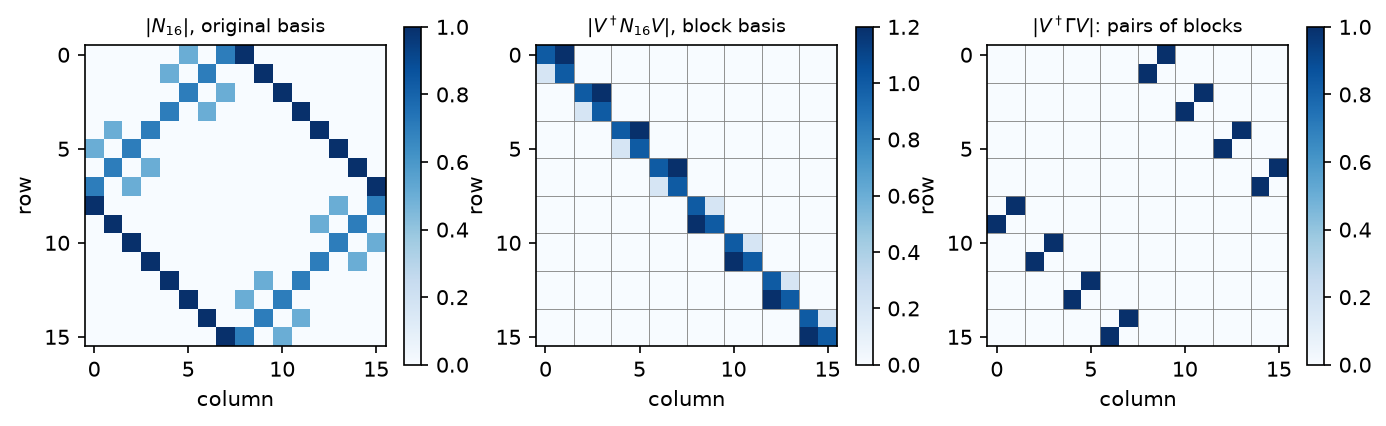

Figure 14a.4 saved as Revision/textbook/figures/14a_4_block_structure.png


In [15]:
N16 = (1 * g8 + sp.I * sp.Rational(1, 2) * g8 * g4
       - sp.I * sp.Rational(7, 10) * g8 * g1)  # M = 1, eps = 1/2, v = 0, kappa k = 7/10
pictures = [
    (np.abs(np.array(N16.evalf(), dtype=complex)), "$|N_{16}|$, original basis"),
    (np.abs(np.array(sp.simplify(V.H * N16 * V).evalf(), dtype=complex)),
     "$|V^\\dagger N_{16} V|$, block basis"),
    (np.abs(np.array(sp.simplify(V.H * Gamma * V).evalf(), dtype=complex)),
     "$|V^\\dagger \\Gamma V|$: pairs of blocks"),
]
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.9))
for ax, (values, title) in zip(axes, pictures):
    image = ax.imshow(values, cmap="Blues", vmin=0.0, interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 5, 10, 15])
    ax.set_yticks([0, 5, 10, 15])
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.grid(False)  # no grid lines over the matrix
    fig.colorbar(image, ax=ax, shrink=0.75)
for ax in axes[1:]:  # mark the 2 x 2 blocks in the block basis
    for edge in np.arange(1.5, 15.0, 2.0):
        ax.axhline(edge, color="gray", linewidth=0.4)
        ax.axvline(edge, color="gray", linewidth=0.4)
save_figure(fig, "block_structure",
            "Absolute values of the matrix entries (row and column 0 to 15, "
            "darker is larger) of the first-order matrix $N_{16}$ of the "
            "stationary equation at $M = 1$, $\\varepsilon = 0.5$, $v = 0$, "
            "$\\kappa k = 0.7$: left in the original spinor basis, where the "
            "entries are spread over the matrix; middle in the block basis $V$, "
            "where only the eight $2\\times2$ blocks on the diagonal are nonzero "
            "(thin lines mark the blocks); right the chirality matrix $\\Gamma$ in "
            "the block basis, which connects each block $(j, s_2, s_3)$ with the "
            "block $(-j, s_2, s_3)$ four positions away.")

## 13. The 2x2 block Hamiltonian, its two types and the matrix Gamma

With the forms of section 12 the Hamiltonian of section 9 becomes, in every
block of type $j$ ($\mathbf k = (k, 0, 0)$):

$$h_j = j\left[-i\sigma_1\frac{d}{dy} + M\sigma_2 + \kappa k\,\sigma_3\right] + v .$$

It depends on $j$ only, not on $s_2, s_3$: there are only TWO types of block,
four blocks of each. The eigenvalue equation $h_j\chi = \varepsilon\chi$ is the
same as the first-order system $\chi' = N\chi$ with
$N = M\sigma_3 - \kappa k\sigma_2 + ij(\varepsilon - v)\sigma_1$. Two exact
relations follow:

- $h_{-1} - v = -(h_{+1} - v)$: the two types have mirrored spectra (for $v = 0$
  the levels of $j = -1$ are the negatives of those of $j = +1$); and
  $\sigma_3 h_j(k)\sigma_3 = h_{-j}(-k)$: the orbital $\sigma_3\chi$ of
  $(-j, -k)$ has the same level as the orbital $\chi$ of $(j, k)$.
- $\sigma_2 h_j(M, k)\sigma_2 = h_{-j}(-M, k)$. This is the block form of the
  chirality MATRIX $\Gamma$: $\Gamma$ maps the block $(j, s_2, s_3)$ onto
  $(-j, s_2, s_3)$ with the $2\times2$ entry $s_2\sigma_2$, so it maps a solution
  with mass $M$ in a block of type $j$ onto a solution with mass $-M$ in a block
  of type $-j$, at the same $k$ and the same level. It also exchanges the two
  brane conditions $\chi_2(0) = 0$ and $\chi_1(0) = 0$. This is the mass-reversing
  matrix map of the pairing theorem T1. (The gammas are real; for a real field
  plain complex conjugation does nothing and is not a charge conjugation. The
  maps of the theory are MATRICES such as $\Gamma$.)

The next cell checks the block Hamiltonian in all eight blocks, the equivalence
with $\chi' = N\chi$, the two type relations and the block form of $\Gamma$.

In [16]:
ok_h = True
for i, (j, a, b) in enumerate(labels):  # the three pieces of h in block i
    Vb = V[:, 2 * i:2 * i + 2]
    ok_h &= sp.simplify(Vb.H * (sp.I * g4 * g8) * Vb + sp.I * j * s1).is_zero_matrix
    ok_h &= sp.simplify(Vb.H * (-g4 * g1) * Vb - j * s3).is_zero_matrix
    ok_h &= sp.simplify(Vb.H * (-sp.I * g4) * Vb - j * s2m).is_zero_matrix
check(ok_h and record_check("block_hamiltonian"),
      "h_j = j[-i sigma1 d/dy + M sigma2 + kappa k sigma3] + v in all 8 blocks",
      record=f"{PY_REPORT}, check block_hamiltonian")
eps = sp.symbols("epsilon", real=True)  # the level


def h_algebraic(j, M_, k_, kap_):
    """The part of h_j - v without the derivative."""
    return j * (M_ * s2m + kap_ * k_ * s3)


def N_matrix(j, M_, k_, eps_, v_, kap_):
    """N of chi' = N chi."""
    return M_ * s3 - kap_ * k_ * s2m + sp.I * j * (eps_ - v_) * s1


kk = sp.symbols("k", real=True)
# h chi = eps chi  <=>  -i j sigma1 chi' = (eps - v - j(M s2 + kappa k s3)) chi
ok_ode = all(sp.simplify(-sp.I * j * s1 * N_matrix(j, M, kk, eps, v, kap)
                         - ((eps - v) * I2 - h_algebraic(j, M, kk, kap)))
             .is_zero_matrix for j in (1, -1))
check(ok_ode and record_check("block_ode_equivalent"),
      "h_j chi = eps chi is the same as chi' = N chi",
      record=f"{PY_REPORT}, check block_ode_equivalent")
d_term = -sp.I * s1  # the matrix in front of d/dy (times j)
ok_types = ((h_algebraic(1, M, kk, kap) + h_algebraic(-1, M, kk, kap))
            .is_zero_matrix
            and (s3 * h_algebraic(1, M, kk, kap) * s3
                 - h_algebraic(-1, M, -kk, kap)).is_zero_matrix
            and (s3 * d_term * s3 + d_term).is_zero_matrix)
check(ok_types and record_check("block_type_relation"),
      "h_(-1) - v = -(h_(+1) - v) and sigma3 h_j(k) sigma3 = h_(-j)(-k)",
      record=f"{PY_REPORT}, check block_type_relation")
YG = sp.simplify(V.H * Gamma * V)
pairs = [(a, b) for a in range(8) for b in range(8)
         if not YG[2 * a:2 * a + 2, 2 * b:2 * b + 2].is_zero_matrix]
say(f"Gamma connects the blocks (from, to): {pairs}")
ok_pairs = (pairs == [(0, 4), (1, 5), (2, 6), (3, 7), (4, 0), (5, 1), (6, 2), (7, 3)]
            and all(YG[2 * a:2 * a + 2, 2 * b:2 * b + 2] == labels[a][1] * s2m
                    for (a, b) in pairs)
            and (Gamma * J + J * Gamma).is_zero_matrix
            and (Gamma * K1 - K1 * Gamma).is_zero_matrix
            and (Gamma * K2 - K2 * Gamma).is_zero_matrix)
check(ok_pairs and record_check("blocks_relation_to_Gamma"),
      "Gamma maps block (j, s2, s3) onto (-j, s2, s3) with the entry s2 sigma2",
      record=f"{PY_REPORT}, check blocks_relation_to_Gamma")
ok_map = ((s2m * h_algebraic(1, M, kk, kap) * s2m
           - h_algebraic(-1, -M, kk, kap)).is_zero_matrix
          and (s2m * d_term * s2m + d_term).is_zero_matrix)
check(ok_map and record_check("block_Gamma_map"),
      "sigma2 h_j(M, k) sigma2 = h_(-j)(-M, k): Gamma reverses the mass",
      record=f"{PY_REPORT}, check block_Gamma_map")

PASS h_j = j[-i sigma1 d/dy + M sigma2 + kappa k sigma3] + v in all 8 blocks
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check block_hamiltonian
PASS h_j chi = eps chi is the same as chi' = N chi
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    block_ode_equivalent
PASS h_(-1) - v = -(h_(+1) - v) and sigma3 h_j(k) sigma3 = h_(-j)(-k)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    block_type_relation
Gamma connects the blocks (from, to): [(0, 4), (1, 5), (2, 6), (3, 7), (4, 0), (5, 1),
    (6, 2), (7, 3)]
PASS Gamma maps block (j, s2, s3) onto (-j, s2, s3) with the entry s2 sigma2
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    blocks_relation_to_Gamma
PASS sigma2 h_j(M, k) sigma2 = h_(-j)(-M, k): Gamma reverses the mass
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check block_Gamma_map


## 14. Rotations of 3-space: only |k| matters

A rotation by the angle $\theta$ in the $(x_1, x_2)$ plane acts on spinors with
the matrix $R = \cos(\theta/2) + \sin(\theta/2)\gamma^{(x_1)}\gamma^{(x_2)}$. Its
inverse is $\cos(\theta/2) - \sin(\theta/2)\gamma^{(x_1)}\gamma^{(x_2)}$: with
$G = \gamma^{(x_1)}\gamma^{(x_2)}$, $c = \cos(\theta/2)$, $s = \sin(\theta/2)$
and $G^2 = -1$ one gets $(c + sG)(c - sG) = c^2 - s^2G^2 = c^2 + s^2 = 1$.
The next cell checks this, and that $R$ commutes with $\gamma^{(x_8)}$,
$\gamma^{(x_4)}$, $B$ and $C$ (so it does not change the rest of $h$) and that it
turns $k\gamma^{(x_1)}$ into
$k(\cos\theta\,\gamma^{(x_1)} - \sin\theta\,\gamma^{(x_2)})$, the same momentum
in a rotated direction. So the levels depend on $|\mathbf k|$ only, and
$\mathbf k = (k, 0, 0)$ is no loss of generality.

In [17]:
theta = sp.symbols("theta", real=True)
R = sp.cos(theta / 2) * I16 + sp.sin(theta / 2) * g1 * g2  # the spinor rotation
R_inverse = sp.cos(theta / 2) * I16 - sp.sin(theta / 2) * g1 * g2  # its inverse
rotated = sp.simplify(R * (kk * g1) * R_inverse)
ok_rotation = (sp.simplify(R * R_inverse) == I16
               and sp.simplify(rotated - kk * (sp.cos(theta) * g1
                                               - sp.sin(theta) * g2)).is_zero_matrix
               and all((R * Xm - Xm * R).is_zero_matrix for Xm in (g8, g4, B, C)))
check(ok_rotation and record_check("rotation_invariance"),
      "a 3-space rotation commutes with g8, g4, B, C and rotates k: only |k| counts",
      record=f"{PY_REPORT}, check rotation_invariance")

PASS a 3-space rotation commutes with g8, g4, B, C and rotates k: only |k| counts
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    rotation_invariance


## 15. The exact rescaling identity between slices

Look at where the slice $a_{4,0}$ enters the block Hamiltonian: only through
$\kappa k = e^{-Hy}\,(k\,e^{-a_{4,0}})$. Line by line:

1. The 3-space directions form a coordinate torus of size $\ell$; the allowed
   momenta are $\mathbf k = \Delta k\,(n_1, n_2, n_3)$ with integers $n_i$ and
   $\Delta k = 2\pi/\ell$ (the Revision solver uses $\Delta k = 0.25$).
2. At the slice $a_{4,0}$ the lattice $\Delta k\,\mathbf n$ therefore acts exactly
   like the lattice $\Delta k\,e^{-a_{4,0}}\,\mathbf n$ at the slice 0: every
   level and every orbital is the same.
3. Densities carry the factor $P = e^{-6Hy}/(\ell^3 v_t)$ ($v_t$ the coordinate
   volume of the extra times). The slice-0 problem with the spacing
   $\Delta k\,e^{-a}$ has the box size $\ell e^{a}$; choosing its extra-time
   volume $v_t e^{-3a}$ gives $(\ell e^a)^3 v_t e^{-3a} = \ell^3 v_t$: the SAME
   factor $P$, so the same proper densities.

Hence, exactly (for the free gas, with the interaction, at every temperature):
$\mathrm{KS}(a_{4,0}; \Delta k, v_t, \lambda) = \mathrm{KS}(0; \Delta k\,
e^{-a_{4,0}}, v_t e^{-3a_{4,0}}, \lambda)$. Equivalently, with the same box
$v_t$ and the coupling $\lambda e^{3a_{4,0}}$, with every proper density
multiplied by $e^{-3a_{4,0}}$ (the coupling enters only as $\lambda$ times a
density). The next cell verifies the three statements with sympy and then
computes the partner spacings and extra-time volumes of the four later slices,
which the Rust solver used to solve every partner problem independently; they
must equal the columns `partner_dk` and `partner_v_t` of the Revision record
`rescaling.csv`.

In [18]:
a_sym, y_sym = sp.symbols("a y", real=True)
ell, v_t, lam = sp.symbols("ell v_t lambda", positive=True)


def h_slice(j, k_, a_):
    """The algebraic part of h_j at the slice a4,0 = a_ (kappa k with e^(-a))."""
    return j * (M * s2m + sp.exp(-H * y_sym - a_) * k_ * s3)


def proper_factor(ell_, v_t_):
    """The factor P = e^(-6Hy)/(ell^3 v_t) of the proper densities."""
    return sp.exp(-6 * H * y_sym) / (ell_ ** 3 * v_t_)


ok_h_slice = all(sp.simplify(h_slice(j, kk, a_sym)
                             - h_slice(j, kk * sp.exp(-a_sym), 0)).is_zero_matrix
                 for j in (1, -1))
ok_box = sp.simplify(proper_factor(ell, v_t) - proper_factor(
    ell * sp.exp(a_sym), v_t * sp.exp(-3 * a_sym))) == 0
ok_lambda = sp.simplify(lam * proper_factor(ell, v_t) - lam * sp.exp(3 * a_sym)
                        * proper_factor(ell * sp.exp(a_sym), v_t)) == 0
check(ok_h_slice and ok_box and ok_lambda and record_check("rescaling_identity"),
      "KS(a4,0; dk, v_t, lambda) = KS(0; dk e^(-a4,0), v_t e^(-3 a4,0), lambda)",
      record=f"{PY_REPORT}, check rescaling_identity")
rows = repository_file("Revision/kohn_sham/results/rescaling/rescaling.csv") \
    .read_text(encoding="utf-8").splitlines()
header = rows[0].split(",")
table = [dict(zip(header, row.split(","))) for row in rows[1:]]
worst = 0.0
for a in slices[1:]:
    dk_partner = 0.25 * np.exp(-a)  # the partner lattice spacing
    vt_partner = 1.0 * np.exp(-3 * a)  # the partner extra-time volume (v_t = 1)
    say(f"slice a4,0 = {a}: partner dk = {dk_partner:.12f}, "
        f"partner v_t = {vt_partner:.12f}")
    for row in table:
        if float(row["a4"]) == a:
            worst = max(worst, abs(float(row["partner_dk"]) / dk_partner - 1),
                        abs(float(row["partner_v_t"]) / vt_partner - 1))
check(len(table) == 60 and worst < 1e-14,
      "the partner spacings and volumes equal those of all 60 rows of the record",
      record="Revision/kohn_sham/results/rescaling/rescaling.csv, columns "
             "partner_dk and partner_v_t")

PASS KS(a4,0; dk, v_t, lambda) = KS(0; dk e^(-a4,0), v_t e^(-3 a4,0), lambda)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    rescaling_identity
slice a4,0 = 0.5: partner dk = 0.151632664928, partner v_t = 0.223130160148
slice a4,0 = 1.0: partner dk = 0.091969860293, partner v_t = 0.049787068368
slice a4,0 = 1.5: partner dk = 0.055782540037, partner v_t = 0.011108996538
slice a4,0 = 2.0: partner dk = 0.033833820809, partner v_t = 0.002478752177
PASS the partner spacings and volumes equal those of all 60 rows of the record
     reproduces Revision/kohn_sham/results/rescaling/rescaling.csv, columns partner_dk
    and partner_v_t


The next cell draws the rescaling. Left: the coordinate momenta of the first
shells of the torus lattice, $|\mathbf k| = \Delta k\sqrt{n_1^2 + n_2^2 + n_3^2}$,
enter the equation as $|\mathbf k|\,e^{-a_{4,0}}$; on a logarithmic axis these are
parallel straight lines falling with slope $-1$ along the history: all
3-momenta are redshifted by the same factor. Right: the proper volumes at the
brane ($y = 0$) of the 3-space box, $(\ell e^{a_{4,0}})^3$, which grows, and of
the extra-time box, $v_t e^{-3a_{4,0}}$, which deflates; their product, the
proper 7-volume $\ell^3 v_t$, is the same at every slice, which is why the
proper densities are the same in the partner problem.

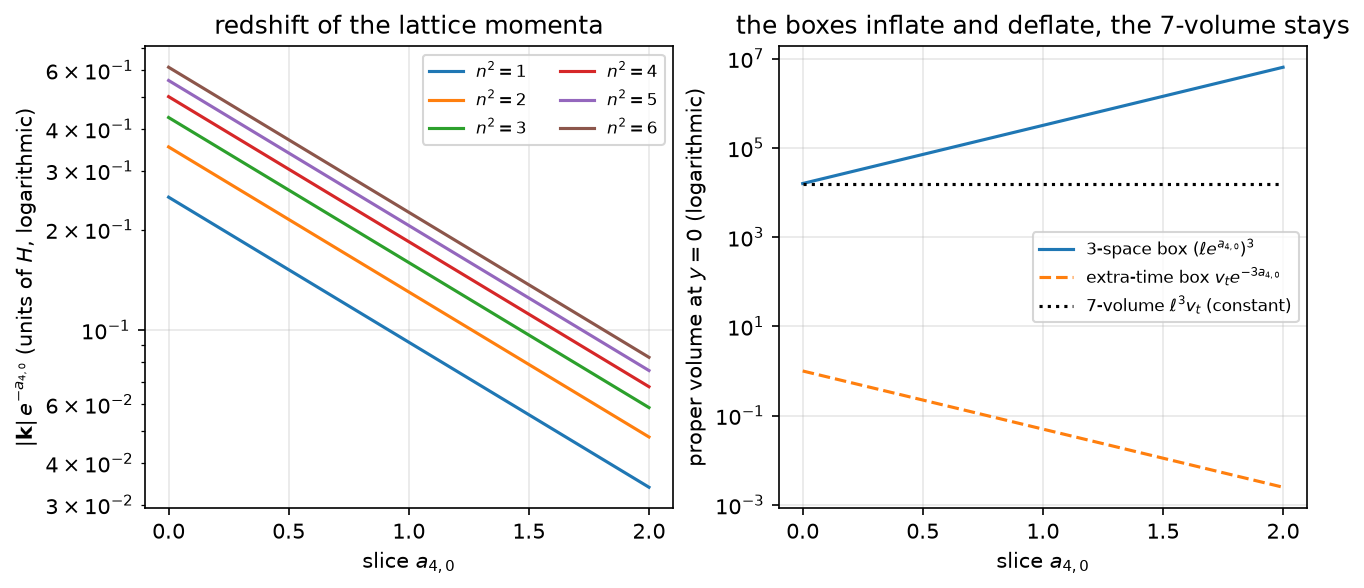

Figure 14a.5 saved as Revision/textbook/figures/14a_5_rescaling.png


In [19]:
ell_value = 2 * np.pi / 0.25  # the coordinate box size of the solver (dk = 0.25)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
for n2 in (1, 2, 3, 4, 5, 6):  # the first shells n1^2 + n2^2 + n3^2
    left.semilogy(a4_values, 0.25 * np.sqrt(n2) * np.exp(-a4_values),
                  label=f"$n^2 = {n2}$")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("$|\\mathbf{k}|\\,e^{-a_{4,0}}$ (units of $H$, logarithmic)")
left.set_title("redshift of the lattice momenta")
left.legend(fontsize=8, ncol=2)
right.semilogy(a4_values, (ell_value * np.exp(a4_values)) ** 3,
               label="3-space box $(\\ell e^{a_{4,0}})^3$")
right.semilogy(a4_values, np.exp(-3 * a4_values), "--",
               label="extra-time box $v_t e^{-3a_{4,0}}$")
right.semilogy(a4_values, ell_value ** 3 * np.exp(3 * a4_values)
               * np.exp(-3 * a4_values), ":", color="black",
               label="7-volume $\\ell^3 v_t$ (constant)")
right.set_xlabel("slice $a_{4,0}$")
right.set_ylabel("proper volume at $y = 0$ (logarithmic)")
right.set_title("the boxes inflate and deflate, the 7-volume stays")
right.legend(fontsize=8)
save_figure(fig, "rescaling",
            "The exact rescaling identity. Left: the momenta of the first six "
            "lattice shells, $|\\mathbf{k}| e^{-a_{4,0}}$ with "
            "$|\\mathbf{k}| = 0.25\\sqrt{n^2}$ (units of $H$), against the slice "
            "$a_{4,0}$ from 0 to 2 on a logarithmic vertical axis: parallel "
            "straight lines, every 3-momentum is redshifted by the same factor "
            "$e^{-a_{4,0}}$. Right: the proper volume of the 3-space box "
            "$(\\ell e^{a_{4,0}})^3$ with $\\ell = 2\\pi/0.25$ (solid, growing), of "
            "the extra-time box $v_t e^{-3a_{4,0}}$ with $v_t = 1$ (dashed, "
            "deflating) and their product $\\ell^3 v_t$ (dotted, constant), all at "
            "the brane $y = 0$; a slice $a_{4,0}$ is therefore the slice 0 with "
            "the lattice spacing $0.25 e^{-a_{4,0}}$ and the same proper 7-volume.")

## 16. The last check

The last cell checks that the five figure files exist and prints the number of
checks that passed.

In [20]:
figure_names = ["14a_1_hidden_coordinate.png", "14a_2_inflation_deflation.png",
                "14a_3_spin_connection_terms.png", "14a_4_block_structure.png",
                "14a_5_rescaling.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all five figure files of this notebook exist")
all_checks_passed()

PASS all five figure files of this notebook exist
ALL 28 CHECKS PASSED (notebook 14a)


## 17. What this notebook showed

- The hidden coordinate $y = \ln(\sin z)/(6H)$ turns the author's metric into the
  warped form with $W = e^{Hy}$; the 7-volume factor $W^6$ does not contain
  $a_4$ (PROVED; reproduces the Revision checks).
- In the Dirac operator the spin connection contributes only $3H\gamma^{(x_8)}$,
  for every history $a_4(x_4)$: the time-direction pieces $+\frac32 a_4'$ of the
  three inflating directions and $-\frac32 a_4'$ of the three deflating extra
  times cancel exactly (PROVED).
- The factor $W^{-3}$ removes this term; the equation becomes
  $i\partial_{x_4}\chi = h\chi$ with a Hermitian $h$ (PROVED).
- $J, K_1, K_2$ split the 16 components into eight blocks of two; the block
  basis equals the one in `Revision/kohn_sham/ks-theory.json` entry by entry; in
  each block $h_j = j[-i\sigma_1 d/dy + M\sigma_2 + \kappa k\sigma_3] + v$ with
  only two types $j = \pm1$ (PROVED).
- The chirality matrix $\Gamma$ pairs the block types and maps mass $M$ to $-M$:
  a matrix map, the one of the pairing theorem T1 (PROVED here at the level of the
  block equation).
- The slice of the prescribed deflating history enters only as
  $k\,e^{-a_{4,0}}$: a later slice is the slice 0 with redshifted lattice
  momenta and the same proper 7-volume (the exact rescaling identity, PROVED; the
  partner numbers equal those of the Rust solver's record).
- ASSUMED: the good sector (no dependence on the extra times). PRESCRIBED
  BACKGROUND: the history $a_4 = AHx_4$.